In [14]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import llowfsc_sim as llowfsc
import scoob_llowfsc.scoob_model as scoobm
import scoob_llowfsc.detector as detector

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')
iefc_data = utils.load_pickle('sim-data/example_iefc_data.pkl')
dh_command = iefc_data['commands'][-1]

hadamard_svd_data = utils.load_pickle('sim-data/llowfsc_hadamard_svd_data.pkl')
hsvd_dm_modes = hadamard_svd_data['control_modes']
hsvd_wfs_modes = hadamard_svd_data['wfs_modes']

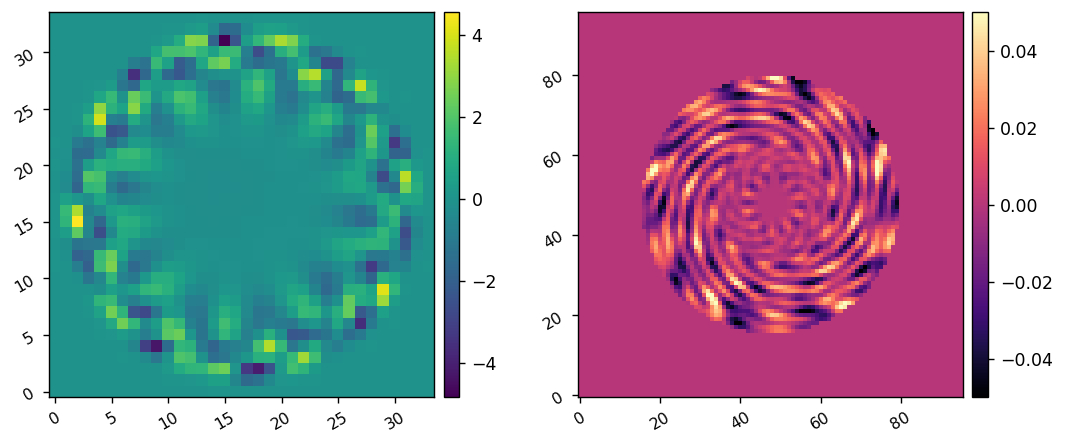

In [15]:
i = 100
vmax = 0.05
imshow2(
    hsvd_dm_modes[i], hsvd_wfs_modes[i], 
    cmap1='viridis', 
    vmin2=-vmax, vmax2=vmax,
)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


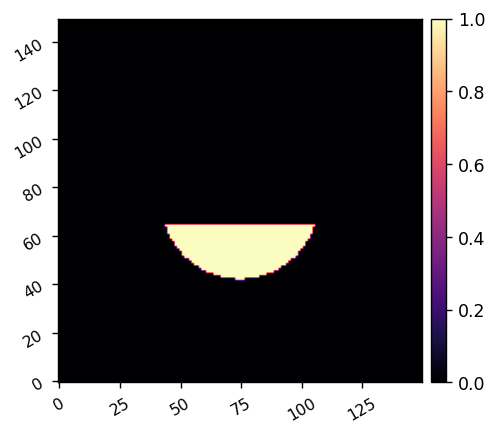

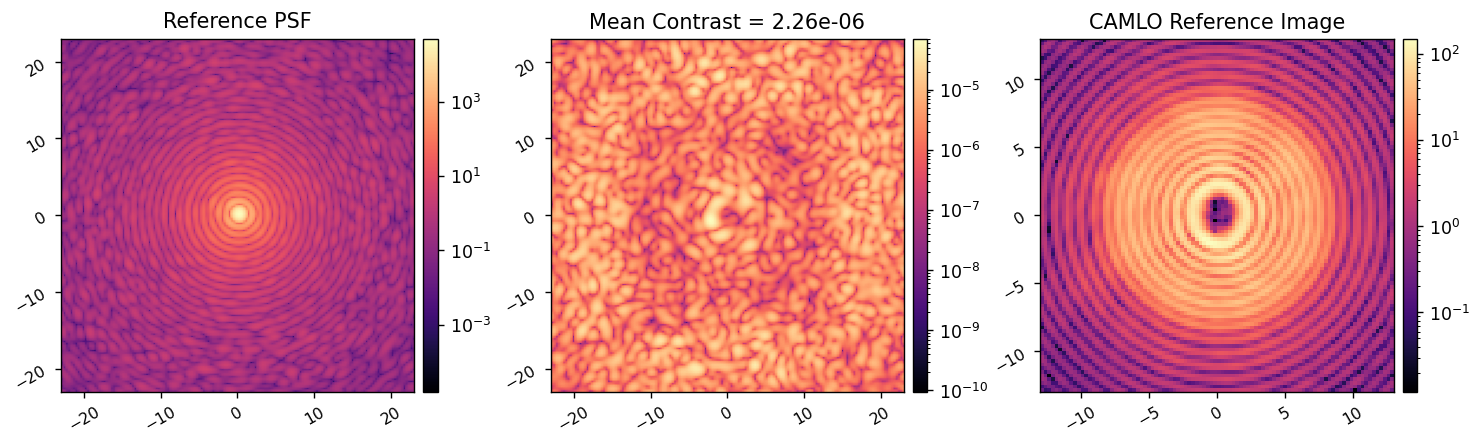

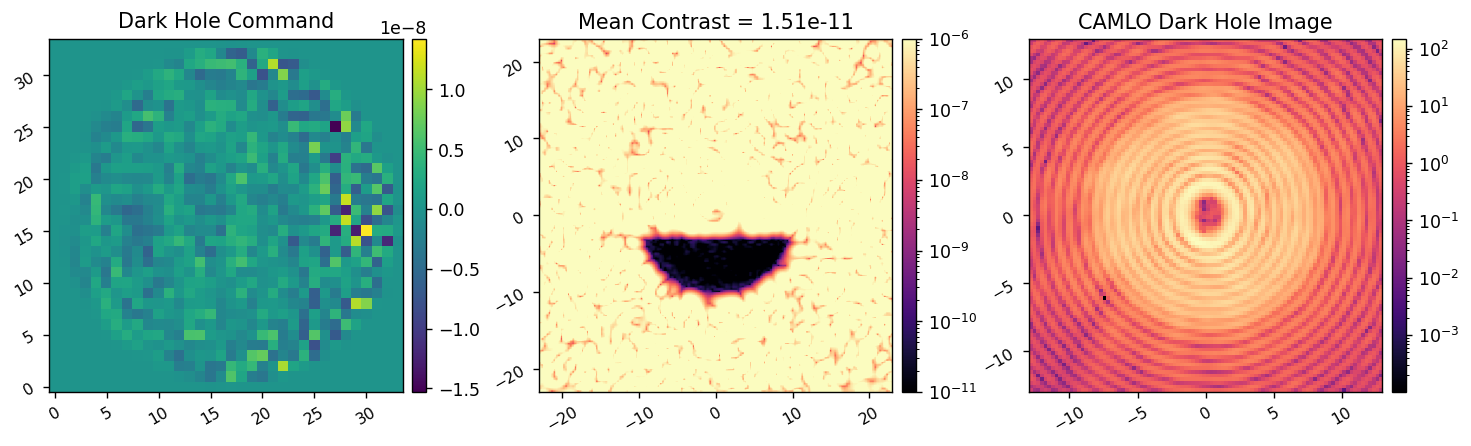

In [48]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
)
M.reset_dm()
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

iwa = 3
owa = 10
dark_hole_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)
imshow1(dark_hole_mask)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im_ref = M.snap_camsci()
contrast_ref = xp.mean(camsci_im_ref[dark_hole_mask])

M.llowfsc_defocus = 2.75e-3
camlo_im_ref = M.snap_camlo()

imshow3(
    ref_psf, camsci_im_ref, camlo_im_ref,
    'Reference PSF', f'Mean Contrast = {contrast_ref:.2e}', 'CAMLO Reference Image',
    pxscl1=M.camsci_pxscl_lamDc, pxscl2=M.camsci_pxscl_lamDc, pxscl3=M.camlo_pxscl_lamDc,
    lognorm=1, 
)

M.add_dm(dh_command, 3)
camsci_im_dh0 = M.snap_camsci()
contrast_dh0 = xp.mean(camsci_im_dh0[dark_hole_mask])
camlo_im_dh = M.snap_camlo()
M.add_dm(-dh_command, 3)

imshow3(
    dh_command, camsci_im_dh0, camlo_im_dh,
    'Dark Hole Command', f'Mean Contrast = {contrast_dh0:.2e}', 'CAMLO Dark Hole Image',
    pxscl2=M.camsci_pxscl_lamDc, pxscl3=M.camlo_pxscl_lamDc,
    cmap1='viridis',
    lognorm2=1, vmin2=1e-11, vmax2=1e-6,
    lognorm3=1,
)


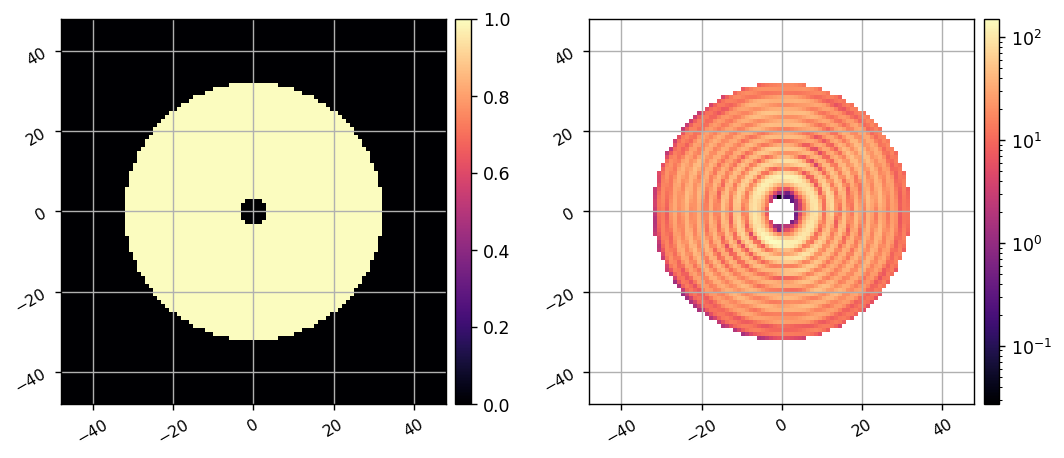

In [17]:
reload(llowfsc)
irad = 3
orad = 32
llowfsc_mask = utils.create_annular_focal_plane_mask(M.ncamlo, 1, irad, orad, edge=None, )
imshow2(llowfsc_mask, camlo_im_ref * llowfsc_mask, grid=True, pxscl=1, lognorm2=True)

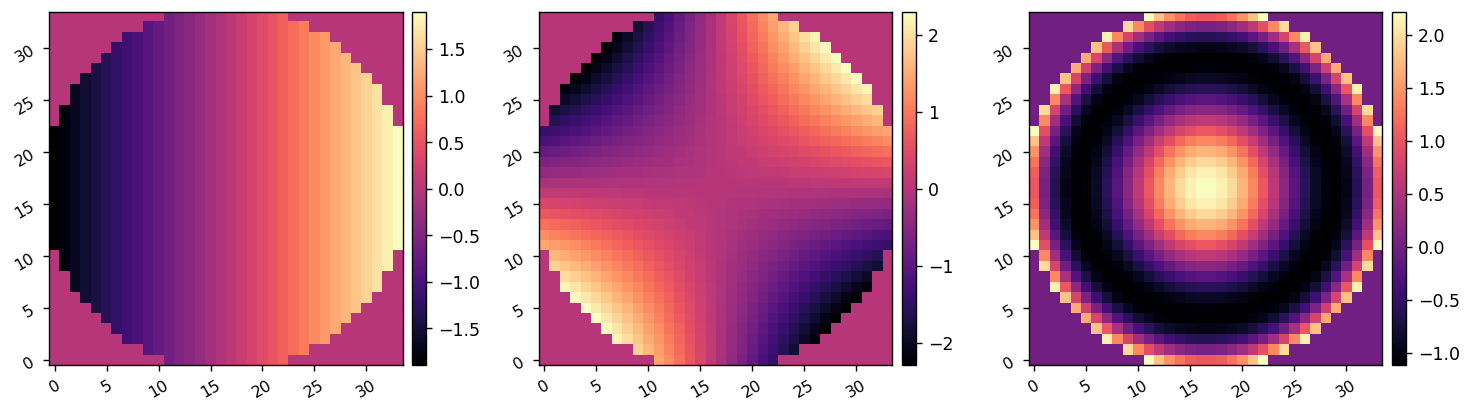

In [18]:
reload(utils)
zernike_modes = utils.create_zernike_modes(M.dm_mask, nmodes=10, remove_modes=1)
zer_modal_matrix = zernike_modes[:, M.dm_mask]
imshow3(zernike_modes[0], zernike_modes[3], zernike_modes[-1])

In [21]:
reload(llowfsc)
M.reset_dm()

M.setattr('use_vortex', True)
z_rm, z_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    zernike_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)

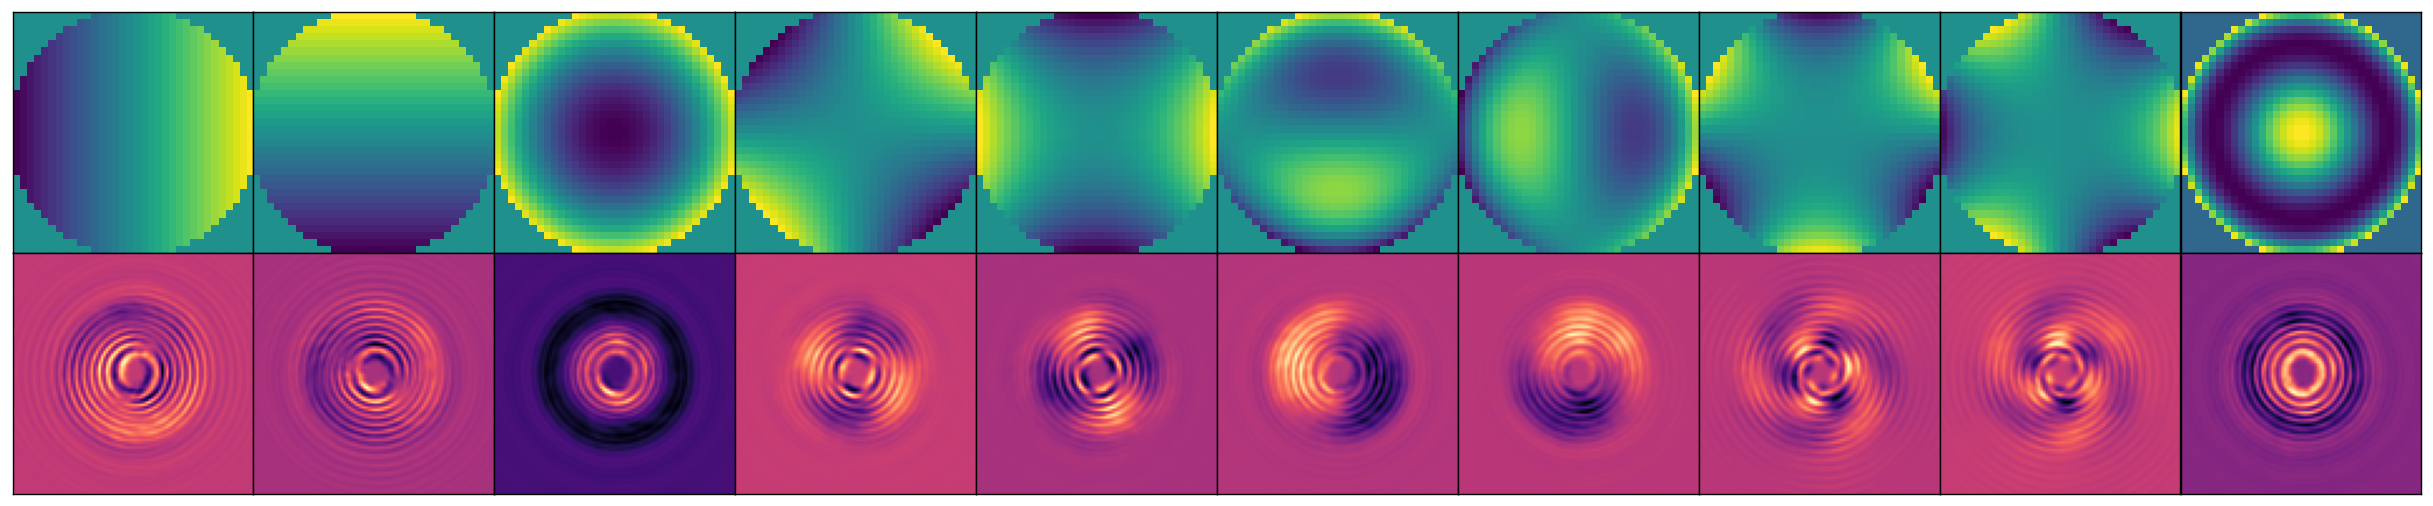

In [22]:
reload(llowfsc)
llowfsc.plot_responses(zernike_modes, z_response_cube)
# llowfsc.plot_responses(zernike_modes[10:], z_response_cube[10:])

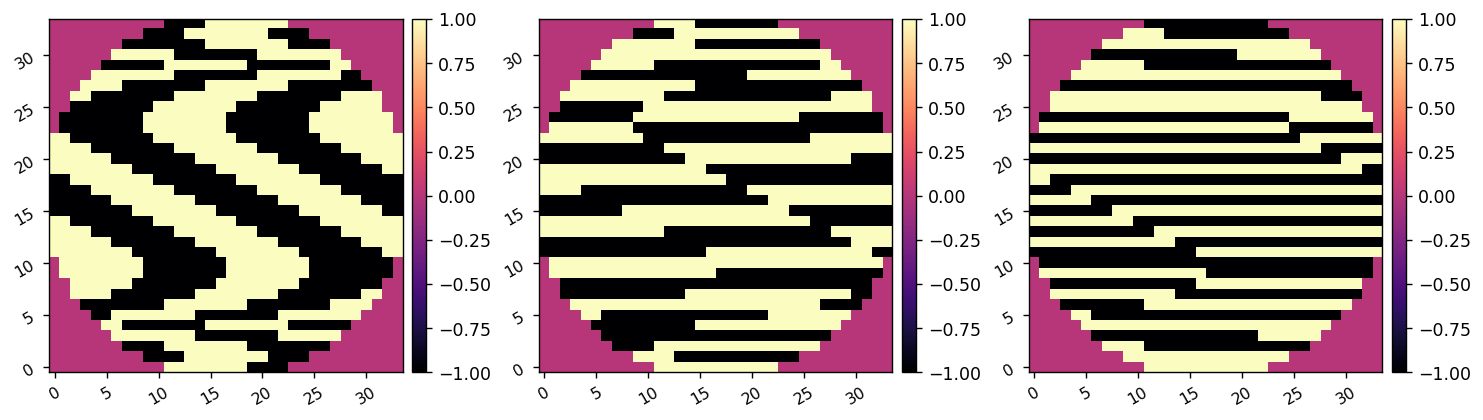

In [ ]:
hadamard_modes = utils.create_hadamard_modes(M.dm_mask)
had_modal_matrix = hadamard_modes[:, M.dm_mask]
imshow3(hadamard_modes[8], hadamard_modes[80], hadamard_modes[800])

In [27]:
reload(llowfsc)
M.reset_dm()
M.setattr('use_vortex', True)

h_rm, h_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    hadamard_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)

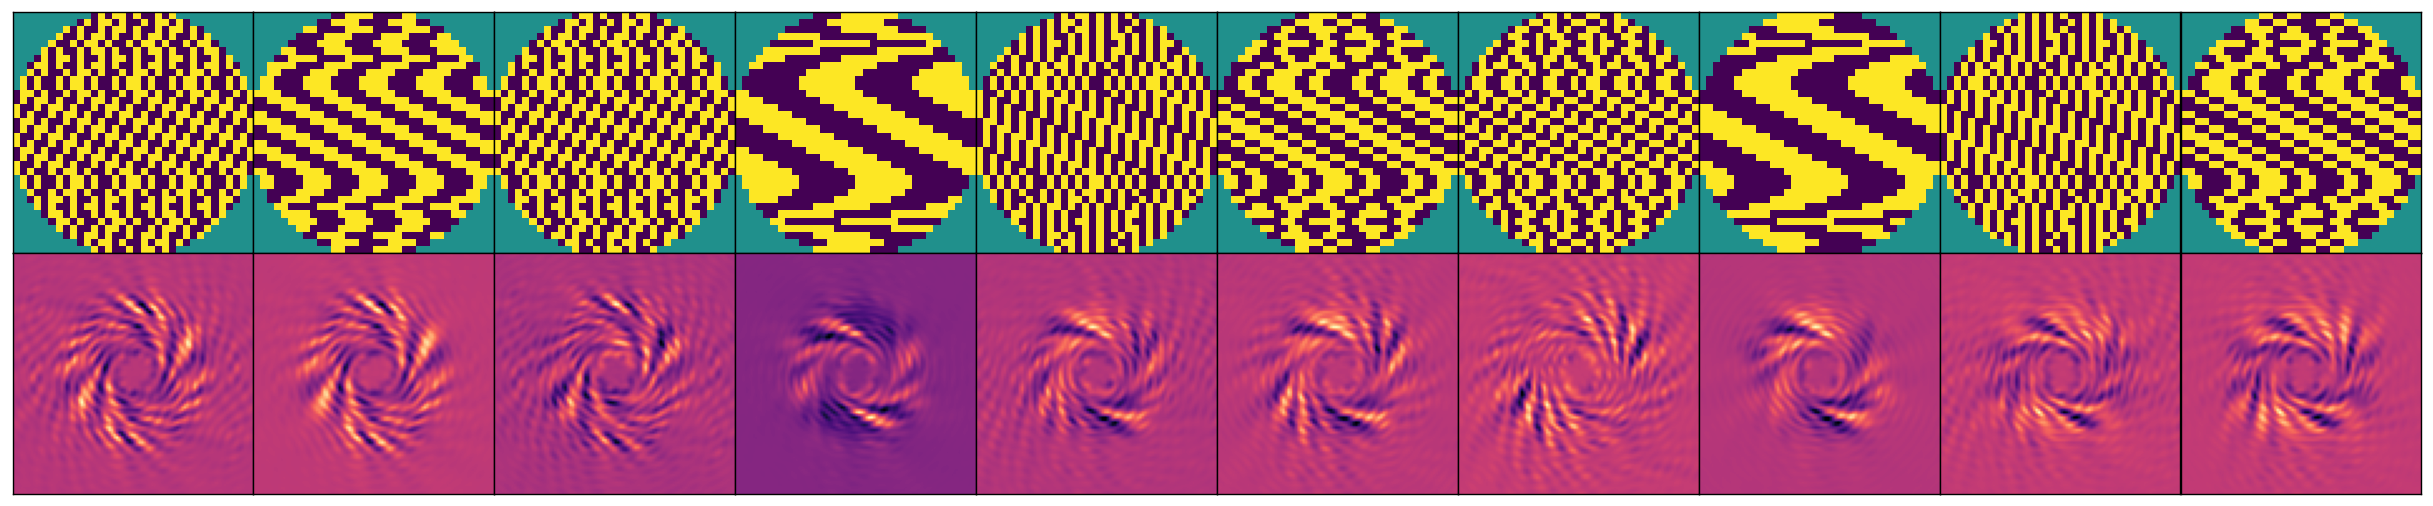

In [28]:
reload(llowfsc)
istart = 5
llowfsc.plot_responses(hadamard_modes[istart:], h_response_cube[istart:])

In [24]:
reload(llowfsc)
M.reset_dm()
M.setattr('use_vortex', True)

Ncutoff = 256
hsvd_control_modes = hsvd_dm_modes[:Ncutoff]
hsvd_modal_matrix = hsvd_control_modes[:, M.dm_mask]

hsvd_rm, hsvd_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    hsvd_control_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)


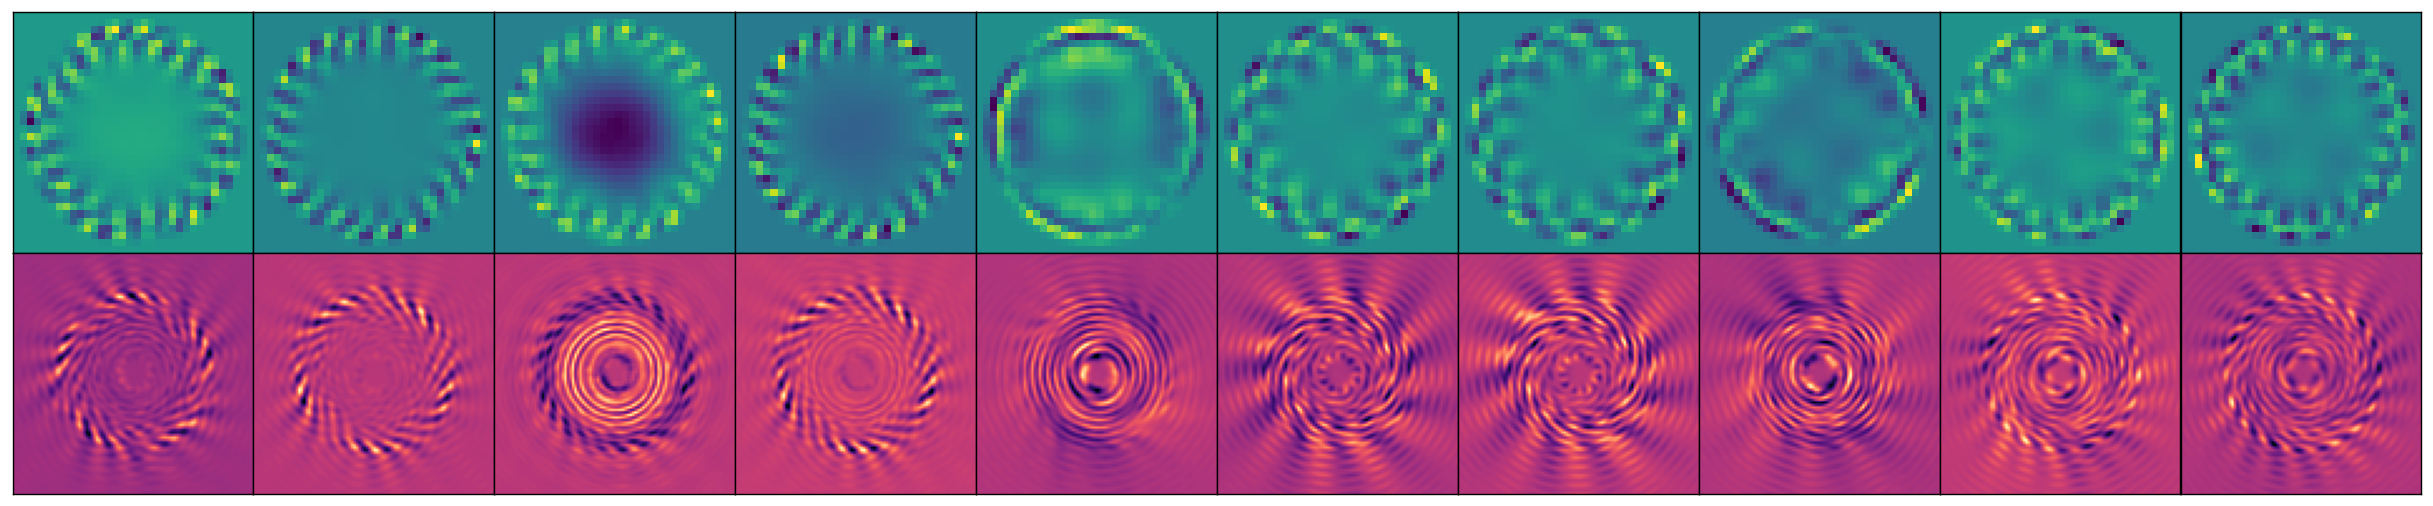

In [25]:
reload(llowfsc)
istart = 103
llowfsc.plot_responses(hsvd_control_modes[istart:], hsvd_response_cube[istart:])

In [29]:
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=10, remove_modes=1)

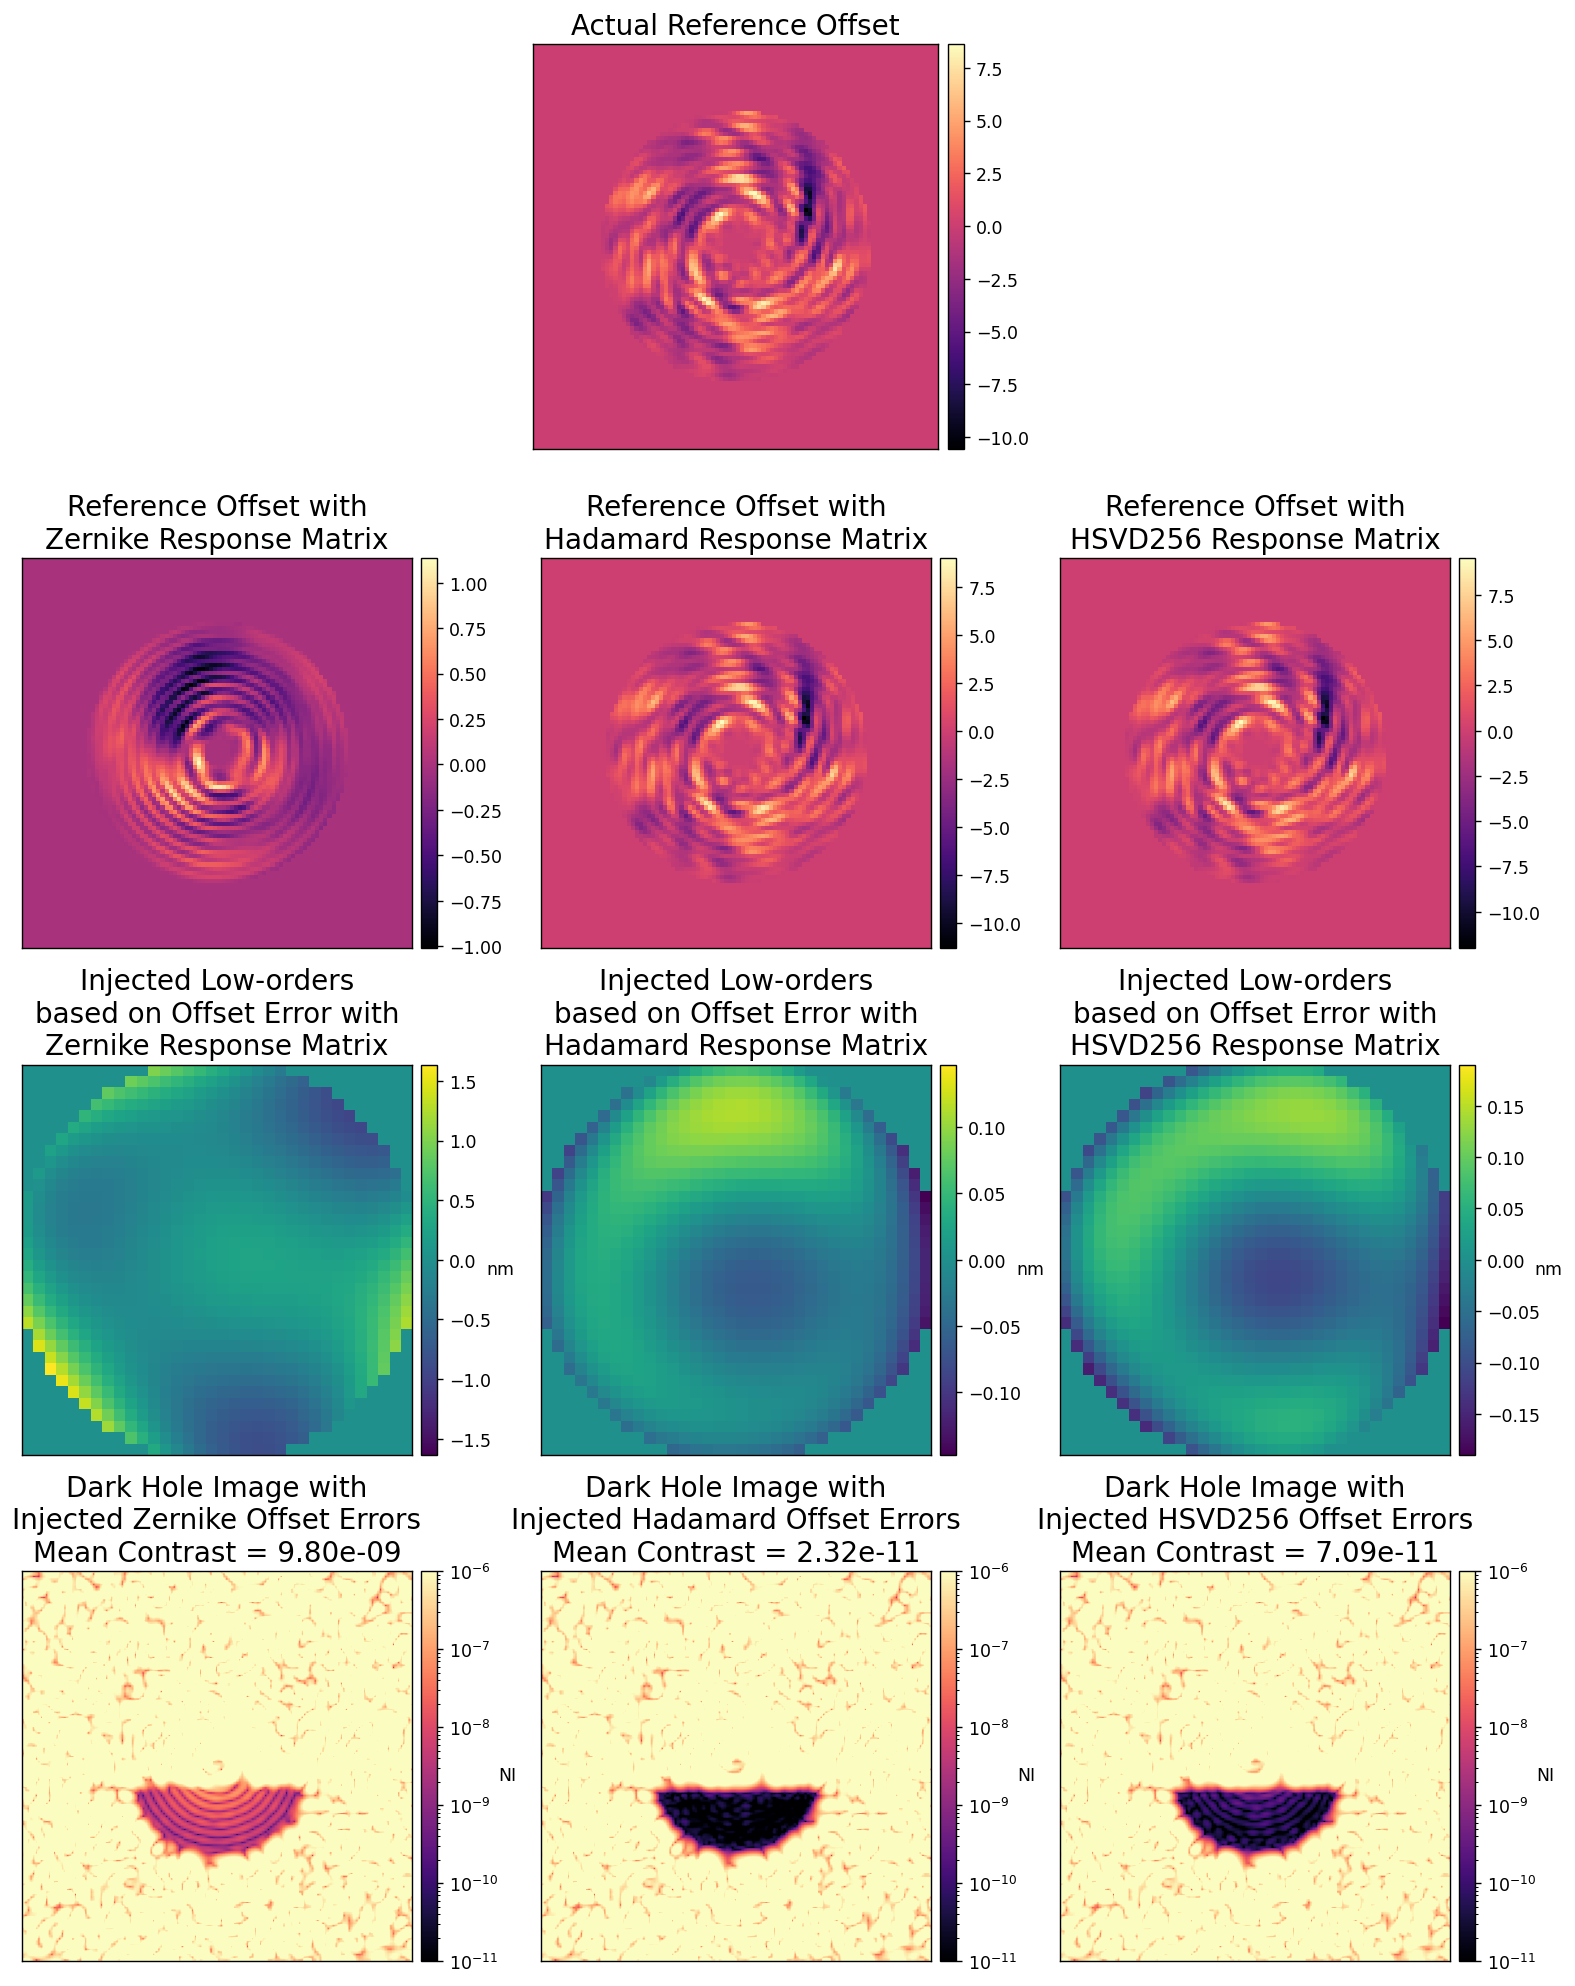

In [47]:
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']
M.reset_dm()
M.add_dm(dh_command, 3)
ref_offset_truth = (M.snap_camlo() - camlo_im_ref) * llowfsc_mask

ref_offset_zer = xp.zeros_like(camlo_im_ref)
ref_offset_zer[llowfsc_mask] = z_rm.dot( zer_modal_matrix.dot( dh_command[M.dm_mask] ) / 952 )

ref_offset_had = xp.zeros_like(camlo_im_ref)
ref_offset_had[llowfsc_mask] = h_rm.dot( had_modal_matrix.dot( dh_command[M.dm_mask] ) / 1024)

ref_offset_hsvd = xp.zeros_like(camlo_im_ref)
ref_offset_hsvd[llowfsc_mask] = hsvd_rm.dot( hsvd_modal_matrix.dot( dh_command[M.dm_mask] ) / 952)

control_matrix = utils.TikhonovInverse(z_rm, 0)

zer_error = llowfsc_mask*ref_offset_truth - ref_offset_zer
zer_coeff = control_matrix.dot(zer_error[llowfsc_mask])
# zer_offset_lo_opd = xp.sum( zer_coeff[:, None, None] * wfe_modes, axis=0)
# M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + zer_offset_lo_opd
zer_offset_lo_opd = xp.sum( zer_coeff[:, None, None] * zernike_modes, axis=0)
M.set_dm(zer_offset_lo_opd, 2)
camsci_im_zer_offset = M.snap_camsci()
contrast_zer_offset = xp.mean(camsci_im_zer_offset[dark_hole_mask])

had_error = llowfsc_mask*ref_offset_truth - ref_offset_had
had_coeff = control_matrix.dot(had_error[llowfsc_mask])
# had_offset_lo_opd = xp.sum( had_coeff[:, None, None] * wfe_modes, axis=0)
# M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + had_offset_lo_opd
had_offset_lo_opd = xp.sum( had_coeff[:, None, None] * zernike_modes, axis=0)
M.set_dm(had_offset_lo_opd, 2)
camsci_im_had_offset = M.snap_camsci()
contrast_had_offset = xp.mean(camsci_im_had_offset[dark_hole_mask])

hsvd_error = llowfsc_mask*ref_offset_truth - ref_offset_hsvd
hsvd_coeff = control_matrix.dot(hsvd_error[llowfsc_mask])
# hsvd_offset_lo_opd = xp.sum( hsvd_coeff[:, None, None] * wfe_modes, axis=0)
# M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + hsvd_offset_lo_opd
hsvd_offset_lo_opd = xp.sum( hsvd_coeff[:, None, None] * zernike_modes, axis=0)
M.set_dm(hsvd_offset_lo_opd, 2)
camsci_im_hsvd_offset = M.snap_camsci()
contrast_hsvd_offset = xp.mean(camsci_im_hsvd_offset[dark_hole_mask])


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, CenteredNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, Normalize

figsize = (15,20)
dpi = 125
title_fz = 16

fig = plt.figure(figsize=figsize, dpi=dpi)
gs = GridSpec(4, 3, figure=fig)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(ensure_np_array(ref_offset_truth), cmap='magma')
ax.set_title('Actual Reference Offset', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
# cbar.ax.set_ylabel('m', rotation=0, labelpad=7)
# ax.set_position([0.05, 0.505, 0.3, 0.3]) 

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(ensure_np_array(ref_offset_zer), cmap='magma')
ax.set_title('Reference Offset with\nZernike Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[1,1])
im = ax.imshow(ensure_np_array(ref_offset_had), cmap='magma')
ax.set_title('Reference Offset with\nHadamard Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[1,2])
im = ax.imshow(ensure_np_array(ref_offset_hsvd), cmap='magma')
ax.set_title(f'Reference Offset with\nHSVD{Ncutoff} Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[2,0])
im = ax.imshow(ensure_np_array(zer_offset_lo_opd)*1e9, cmap='viridis', norm=CenteredNorm())
ax.set_title('Injected Low-orders\nbased on Offset Error with\nZernike Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[2,1])
im = ax.imshow(ensure_np_array(had_offset_lo_opd)*1e9, cmap='viridis', norm=CenteredNorm())
ax.set_title('Injected Low-orders\nbased on Offset Error with\nHadamard Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[2,2])
im = ax.imshow(ensure_np_array(hsvd_offset_lo_opd)*1e9, cmap='viridis', norm=CenteredNorm())
ax.set_title(f'Injected Low-orders\nbased on Offset Error with\nHSVD{Ncutoff} Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[3,0])
im = ax.imshow(ensure_np_array(camsci_im_zer_offset), cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6))
ax.set_title(f'Dark Hole Image with\nInjected Zernike Offset Errors\nMean Contrast = {contrast_zer_offset:.2e}', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[3,1])
im = ax.imshow(ensure_np_array(camsci_im_had_offset), cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6))
ax.set_title(f'Dark Hole Image with\nInjected Hadamard Offset Errors\nMean Contrast = {contrast_had_offset:.2e}', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[3,2])
im = ax.imshow(ensure_np_array(camsci_im_hsvd_offset), cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6))
ax.set_title(f'Dark Hole Image with\nInjected HSVD{Ncutoff} Offset Errors\nMean Contrast = {contrast_hsvd_offset:.2e}', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

plt.subplots_adjust(wspace=0.25, hspace=0.25)
